In [95]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.inspection import permutation_importance

from sklearn.metrics.pairwise import rbf_kernel

from sklearn.dummy import DummyRegressor

# Load Database

# California Housing Price Prediction

## Project Overview

This project develops a machine learning pipeline for predicting median house values in California districts.

The project focuses on:

- Exploratory Data Analysis (EDA)
- Stratified train/test splitting
- Data preprocessing
- Feature engineering
- Regression model comparison
- Cross-validation
- Hyperparameter tuning
- Model evaluation
- Feature importance analysis
- Error analysis
- Model persistence

The complete workflow is implemented using Scikit-learn pipelines to reduce data leakage and keep preprocessing consistent between training and inference.

## Problem Definition

**Task:** Regression

**Target:** `median_house_value`

**Goal:** Predict the median house value of a California district from demographic, geographic, and housing-related features.

In [96]:
housing = pd.read_csv(
    "california_housing_prices.csv"
)

# Dataset Overview

Before building the predictive models, the dataset is inspected to understand:

- dataset dimensions
- feature types
- missing values
- duplicate observations
- target distribution
- categorical variables

In [97]:
print("Dataset shape:", housing.shape)

display(housing.head())

print("\nData types:")
display(housing.dtypes)

print("\nMissing values:")
display(
    housing.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nDuplicate rows:")
print(housing.duplicated().sum())

print("\nSummary statistics:")
display(housing.describe().T)

Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Data types:


,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object



Missing values:


,0
total_bedrooms,207
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0



Duplicate rows:
0

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


# Exploratory Data Analysis

## Target Distribution

The target variable is inspected to understand its range, central tendency, and distribution.

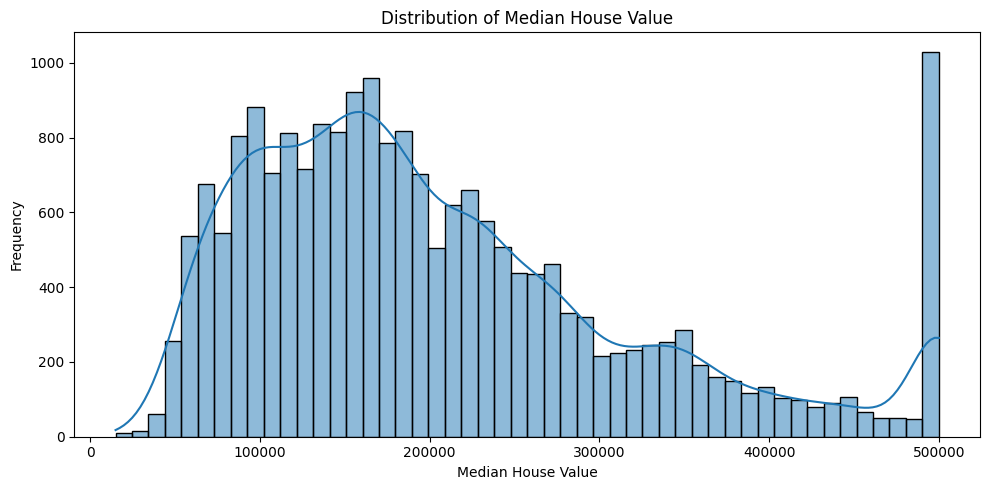

In [98]:
plt.figure(figsize=(10, 5))

sns.histplot(
    housing["median_house_value"],
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Target Ceiling Analysis

The target distribution is examined for a possible upper-value ceiling.
A large concentration of observations at the maximum target value may indicate that the target was capped during data collection.

## Correlation Analysis

Correlation analysis is used to identify numerical features that have strong linear relationships with the target variable.

In [99]:
target_max = housing["median_house_value"].max()

n_at_max = (
    housing["median_house_value"] == target_max
).sum()

pct_at_max = (
    n_at_max / len(housing) * 100
)

print(f"Maximum target value: ${target_max:,.0f}")
print(f"Observations at maximum: {n_at_max}")
print(f"Percentage at maximum: {pct_at_max:.2f}%")

Maximum target value: $500,001
Observations at maximum: 965
Percentage at maximum: 4.68%


In [100]:
numeric_features = housing.select_dtypes(
    include=np.number
).columns

correlation = (
    housing[numeric_features]
    .corr()["median_house_value"]
    .sort_values(ascending=False)
)

display(correlation)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


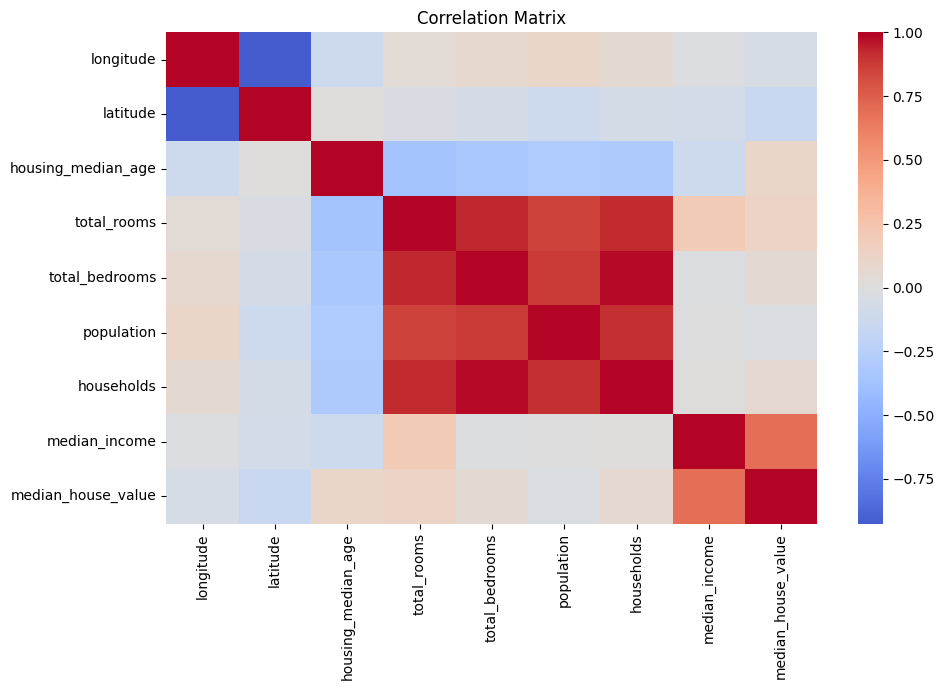

In [101]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    housing[numeric_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Geographic Distribution of House Values

Because the dataset contains latitude and longitude, the spatial distribution of house values can be visualized to identify geographic patterns.

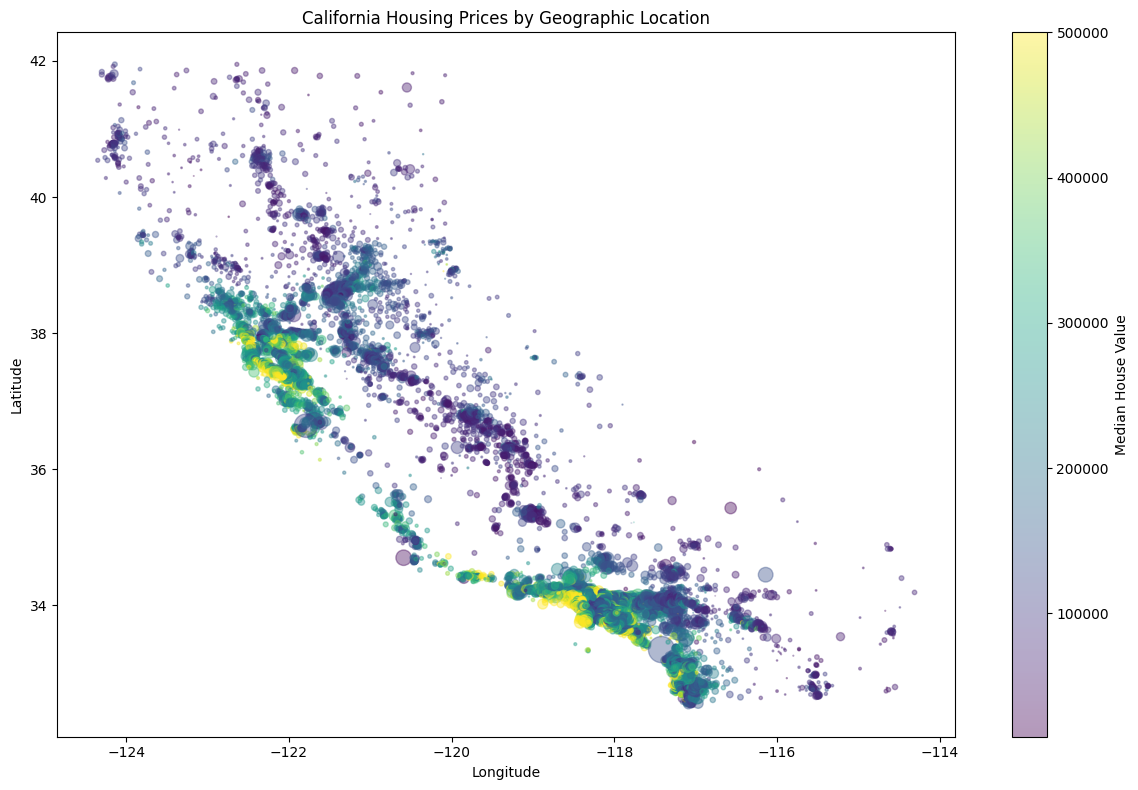

In [102]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    housing["longitude"],
    housing["latitude"],
    c=housing["median_house_value"],
    cmap="viridis",
    alpha=0.4,
    s=housing["population"] / 100,
)

plt.colorbar(scatter, label="Median House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Geographic Location")

plt.tight_layout()
plt.show()

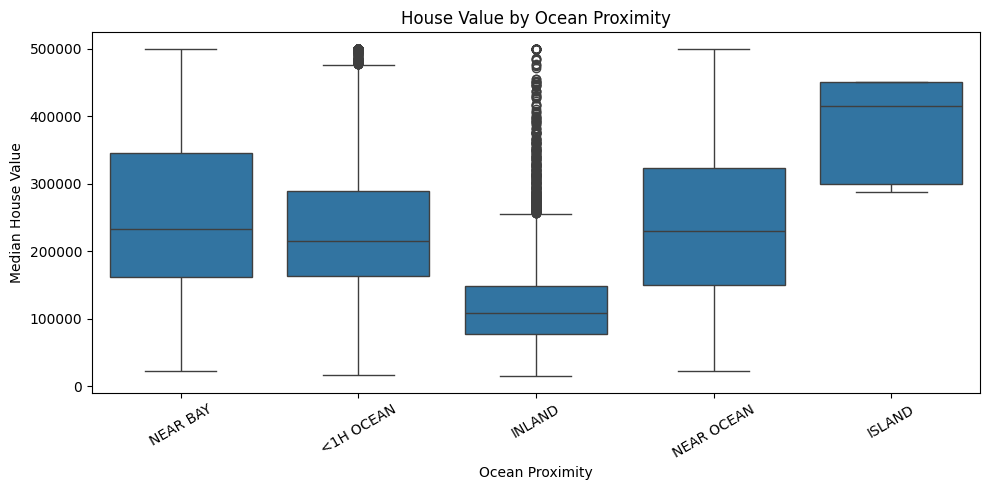

In [103]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=housing,
    x="ocean_proximity",
    y="median_house_value"
)

plt.title("House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [104]:
display(
    housing.groupby("ocean_proximity")["median_house_value"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

,count,mean,median
ocean_proximity,,,
ISLAND,5,380440.000000,414700.0
NEAR BAY,2290,259212.311790,233800.0
NEAR OCEAN,2658,249433.977427,229450.0
<1H OCEAN,9136,240084.285464,214850.0
INLAND,6551,124805.392001,108500.0


# Train/Test Split

A stratified split is used based on `median_income` to preserve a similar income distribution across the training and test sets.

The test set is kept untouched until the final evaluation stage.

In [105]:

housing["income_category"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3., 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=40,
    stratify=housing["income_category"]
)

train_set = train_set.drop(columns="income_category")
test_set = test_set.drop(columns="income_category")


# Separate Features & Target


In [106]:

train_features = train_set.drop(
    columns="median_house_value"
)

train_target = train_set["median_house_value"]

test_features = test_set.drop(
    columns="median_house_value"
)

test_target = test_set["median_house_value"]


# Feature Engineering Functions

In [107]:

def ratio_of_columns(X):
    return X[:, [0]] / X[:, [1]]


def ratio_feature_name(transformer, feature_names_in):
    return ["ratio"]



# Feature Engineering Pipelines

In [108]:
def ratio_pipeline():

    return make_pipeline(

        SimpleImputer(strategy="median"),

        FunctionTransformer(
            ratio_of_columns,
            feature_names_out=ratio_feature_name
        ),

        StandardScaler()

    )


heavy_tail_pipeline = make_pipeline(

    SimpleImputer(strategy="median"),

    FunctionTransformer(
        np.log1p,
        feature_names_out="one-to-one"
    ),

    StandardScaler()

)

housing_age_pipeline = FunctionTransformer(

    rbf_kernel,

    feature_names_out="one-to-one",

    kw_args={
        "Y": [[35]],
        "gamma": 0.1
    }

)

default_numeric_pipeline = make_pipeline(

    SimpleImputer(strategy="median"),

    StandardScaler()

)

categorical_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )

])

### Nonlinear Feature Transformation

The housing median age is represented both as a standardized numerical feature and through an RBF transformation.

The RBF transformation allows tree-based and linear models to capture potential nonlinear relationships between housing age and house value.

In [109]:
all_transformations = ColumnTransformer(

    [

        (
            "bedrooms_per_room",
            ratio_pipeline(),
            ["total_bedrooms", "total_rooms"]
        ),

        (
            "rooms_per_house",
            ratio_pipeline(),
            ["total_rooms", "households"]
        ),

        (
            "people_per_house",
            ratio_pipeline(),
            ["population", "households"]
        ),

        (
            "log_features",
            heavy_tail_pipeline,
            [
                "total_bedrooms",
                "total_rooms",
                "population",
                "households",
                "median_income"
            ]
        ),

        (
            "housing_age_rbf",
            housing_age_pipeline,
            ["housing_median_age"]
        ),

        (
            "categorical",
            categorical_pipeline,
            ["ocean_proximity"]
        )

    ],

    remainder=default_numeric_pipeline

)


# Linear Regression Pipeline

In [110]:

linear_regression_pipeline = Pipeline(

    [

        (
            "preprocessing",
            all_transformations
        ),

        (
            "model",
            LinearRegression()
        )

    ]

)

# Decision Tree Pipeline

In [111]:

decision_tree_pipeline = Pipeline(

    [

        (
            "preprocessing",
            all_transformations
        ),

        (
            "model",
            DecisionTreeRegressor(
                random_state=40
            )
        )

    ]

)

# Naive Baseline

A Dummy Regressor is used as a naive baseline. It predicts the median target value without learning relationships between the input features.

All machine learning models should outperform this baseline to demonstrate meaningful predictive value.

In [112]:
dummy_model = DummyRegressor(
    strategy="median"
)

dummy_cv = -cross_val_score(
    dummy_model,
    train_features,
    train_target,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

print("Dummy Regressor CV MAE:")
print(dummy_cv)

print(f"\nMean CV MAE: {dummy_cv.mean():.2f}")
print(f"Std CV MAE: {dummy_cv.std():.2f}")

Dummy Regressor CV MAE:
[91522.91099001 85826.53375719 87998.07571169 86471.54239855
 88712.95093882]

Mean CV MAE: 88106.40
Std CV MAE: 1996.13


# Train Linear Regression

In [113]:

linear_regression_pipeline.fit(

    train_features,
    train_target

)

linear_predictions = linear_regression_pipeline.predict(
    train_features
)


# Linear Regression Metrics

In [114]:
linear_mae = mean_absolute_error(
    train_target,
    linear_predictions
)

linear_mse = mean_squared_error(
    train_target,
    linear_predictions,
   )

linear_rmse = root_mean_squared_error(
    train_target,
    linear_predictions,
   )

linear_r2 = r2_score(
    train_target,
    linear_predictions
)

print("=" * 60)
print("Linear Regression")
print("=" * 60)

print(f"MAE  : {linear_mae:.2f}")
print(f"MSE : {linear_mse:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")


Linear Regression
MAE  : 52198.95
MSE : 4912042740.98
RMSE : 70085.97
R²   : 0.6291


# Cross Validation

In [115]:

linear_cv = -cross_val_score(

    linear_regression_pipeline,

    train_features,

    train_target,

    scoring="neg_mean_absolute_error",

    cv=5,

    n_jobs=-1

)

print("\nCross Validation (Linear Regression)")
print(pd.Series(linear_cv).describe())



Cross Validation (Linear Regression)
count        5.000000
mean     52336.339200
std        641.998406
min      51472.481506
25%      51900.137092
50%      52561.243511
75%      52669.510720
max      53078.323168
dtype: float64


# Train Decision Tree

In [116]:
decision_tree_pipeline.fit(

    train_features,
    train_target

)

decision_tree_predictions = decision_tree_pipeline.predict(
    train_features
)

# Decision Tree Metrics


In [117]:

decision_tree_mae = mean_absolute_error(
    train_target,
    decision_tree_predictions
)

decision_tree_mse = mean_squared_error(
    train_target,
    decision_tree_predictions
)

decision_tree_rmse = root_mean_squared_error(
    train_target,
    decision_tree_predictions
)

decision_tree_r2 = r2_score(
    train_target,
    decision_tree_predictions
)

print("\n" + "=" * 60)
print("Decision Tree")
print("=" * 60)

print(f"MAE  : {decision_tree_mae:.2f}")
print(f"MSE : {decision_tree_mse:.2f}")
print(f"RMSE : {decision_tree_rmse:.2f}")
print(f"R²   : {decision_tree_r2:.4f}")



Decision Tree
MAE  : 0.00
MSE : 0.00
RMSE : 0.00
R²   : 1.0000


### Interpretation

The Decision Tree achieves nearly perfect performance on the training set. This is expected for an unconstrained decision tree and indicates a strong risk of overfitting.

Therefore, training performance alone is not used to select the final model. Cross-validation and the untouched test set are used for model selection and final evaluation.

# Cross Validation (Decision Tree)

In [118]:

decision_tree_cv = -cross_val_score(

    decision_tree_pipeline,

    train_features,

    train_target,

    scoring="neg_mean_absolute_error",

    cv=5

)

print("\nCross Validation (Decision Tree)")
print(pd.Series(decision_tree_cv).describe())



Cross Validation (Decision Tree)
count        5.000000
mean     46488.614538
std        686.239271
min      45687.625795
25%      45987.359673
50%      46421.758328
75%      47016.366747
max      47329.962144
dtype: float64


# Hyperparameter Tuning

In [119]:
tree_grid_parameters = {

    "preprocessing__housing_age_rbf__kw_args": [

        {
            "Y": [[35.0]],
            "gamma": 0.1
        },

        {
            "Y": [[35.0]],
            "gamma": 0.2
        }

    ],

    "model__max_depth": [
        5,
        10,
        15
    ],

    "model__min_samples_split": [
        2,
        10
    ],

    "model__min_samples_leaf": [
        1,
        5
    ]

}

tree_grid_search = GridSearchCV(

    estimator=decision_tree_pipeline,

    param_grid=tree_grid_parameters,

    scoring="neg_mean_absolute_error",

    cv=5,

    n_jobs=-1,

    return_train_score=True

)

tree_grid_search.fit(
    train_features,
    train_target
)

print("Best Decision Tree Parameters:")
print(tree_grid_search.best_params_)

print("\nBest Decision Tree CV MAE:")
print(-tree_grid_search.best_score_)

Best Decision Tree Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'preprocessing__housing_age_rbf__kw_args': {'Y': [[35.0]], 'gamma': 0.2}}

Best Decision Tree CV MAE:
40675.667249460814


# Random Forest Regression

Random Forest is evaluated as an ensemble method capable of modeling nonlinear relationships and interactions between features.

In [120]:
random_forest_pipeline = Pipeline(
    [
        (
            "preprocessing",
            all_transformations
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=40,
                n_jobs=-1
            )
        )
    ]
)

In [121]:
random_forest_cv = -cross_val_score(
    random_forest_pipeline,
    train_features,
    train_target,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

print("Random Forest CV MAE:")
print(random_forest_cv)

print("\nMean CV MAE:", random_forest_cv.mean())
print("Std CV MAE:", random_forest_cv.std())

Random Forest CV MAE:
[33456.59922343 32413.36275658 33319.94605239 33941.59284676
 32752.79809509]

Mean CV MAE: 33176.85979485282
Std CV MAE: 537.829065470446


In [122]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5]
}

In [123]:
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

rf_grid_search.fit(
    train_features,
    train_target
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms_per_room',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_nam...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        RandomForestRegressor(n_estimators=200,
                                                              n_jobs=-1,
                                                              random_state=40))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2, 5],
                         'model__n_estimators': [100, 200]},
             return_train_score=True, scoring='neg_mean_absolute_error')

In [124]:
print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Random Forest CV MAE:")
print(-rf_grid_search.best_score_)

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Best Random Forest CV MAE:
33059.98583341514


In [125]:
gradient_boosting_pipeline = Pipeline(
    [
        (
            "preprocessing",
            all_transformations
        ),
        (
            "model",
            GradientBoostingRegressor(
                random_state=40
            )
        )
    ]
)

In [126]:
gradient_boosting_cv = -cross_val_score(
    gradient_boosting_pipeline,
    train_features,
    train_target,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

print("Gradient Boosting CV MAE:")
print(gradient_boosting_cv)

print("\nMean CV MAE:", gradient_boosting_cv.mean())
print("Std CV MAE:", gradient_boosting_cv.std())

Gradient Boosting CV MAE:
[36619.16378035 36729.34244014 37589.24367231 36547.39735675
 36608.31550189]

Mean CV MAE: 36818.692550286985
Std CV MAE: 389.7188187397617


In [127]:
"""# Hyperparameter Tuning - Gradient Boosting"""

gb_param_grid = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__learning_rate": [
        0.05,
        0.1
    ],

    "model__max_depth": [
        2,
        3
    ],

    "model__min_samples_leaf": [
        1,
        5
    ]

}

gb_grid_search = GridSearchCV(

    estimator=gradient_boosting_pipeline,

    param_grid=gb_param_grid,

    scoring="neg_mean_absolute_error",

    cv=5,

    n_jobs=-1,

    return_train_score=True

)

gb_grid_search.fit(
    train_features,
    train_target
)

print("Best Gradient Boosting Parameters:")
print(gb_grid_search.best_params_)

print("\nBest Gradient Boosting CV MAE:")
print(-gb_grid_search.best_score_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Best Gradient Boosting CV MAE:
34341.1658632848


# Model Comparison


In [128]:
model_results = pd.DataFrame({

    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "Gradient Boosting (Tuned)"
    ],

    "CV MAE": [
        dummy_cv.mean(),
        linear_cv.mean(),
        -tree_grid_search.best_score_,
        -rf_grid_search.best_score_,
        -gb_grid_search.best_score_
    ],

    "CV MAE Std": [
        dummy_cv.std(),
        linear_cv.std(),
        tree_grid_search.cv_results_["std_test_score"][
            tree_grid_search.best_index_
        ],
        rf_grid_search.cv_results_["std_test_score"][
            rf_grid_search.best_index_
        ],
        gb_grid_search.cv_results_["std_test_score"][
            gb_grid_search.best_index_
        ]
    ]

})

model_results = model_results.sort_values(
    "CV MAE"
).reset_index(drop=True)

display(model_results)

,Model,CV MAE,CV MAE Std
0,Random Forest (Tuned),33059.985833,560.031083
1,Gradient Boosting (Tuned),34341.165863,493.076205
2,Decision Tree (Tuned),40675.667249,373.857131
3,Linear Regression,52336.339200,574.220831
4,Dummy Regressor,88106.402759,1996.133012


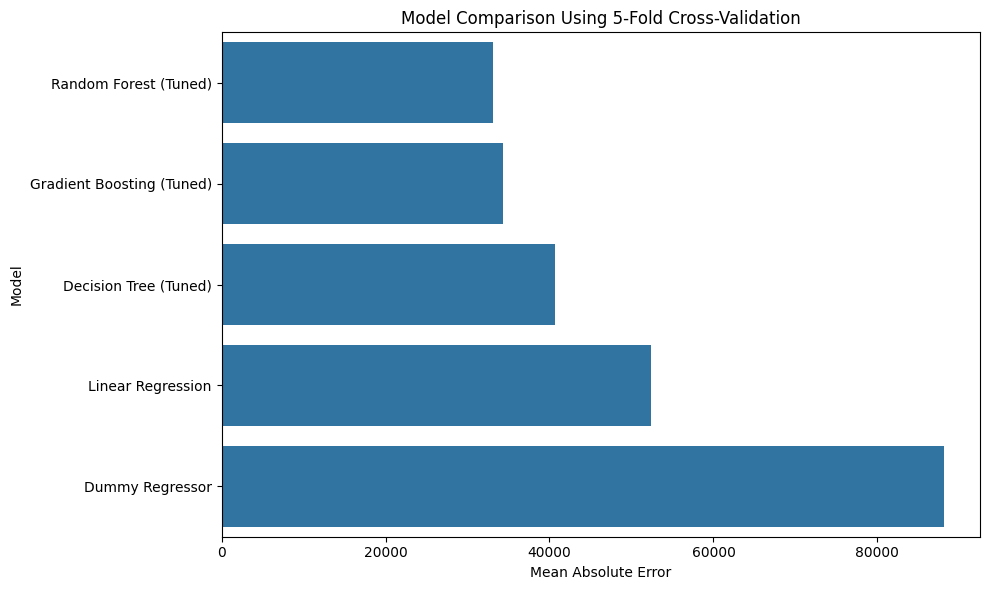

In [129]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="CV MAE",
    y="Model"
)

plt.title(
    "Model Comparison Using 5-Fold Cross-Validation"
)

plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

### Model Selection

Models are compared using 5-fold cross-validation on the training set.

Mean Absolute Error (MAE) is used as the primary selection metric because it is directly interpretable in the same monetary unit as the target variable.

The Dummy Regressor provides a naive reference baseline, while the remaining models learn relationships between the housing features and the target.

Among the trained machine learning models, the tuned Random Forest achieved the lowest cross-validation MAE and was therefore selected as the final model.

The test set remains untouched during model selection and is used only once for the final evaluation of the selected model.

In [130]:
best_model_name = model_results.iloc[0]["Model"]

print("Selected model based on cross-validation:")
print(best_model_name)

Selected model based on cross-validation:
Random Forest (Tuned)


In [131]:
if best_model_name == "Linear Regression":

    final_model = linear_regression_pipeline

elif best_model_name == "Decision Tree (Tuned)":

    final_model = tree_grid_search.best_estimator_

elif best_model_name == "Random Forest (Tuned)":

    final_model = rf_grid_search.best_estimator_

elif best_model_name == "Gradient Boosting (Tuned)":

    final_model = gb_grid_search.best_estimator_

In [132]:
final_model.fit(
    train_features,
    train_target
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms_per_room',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_featur...
                                                                      func=<function rbf_kernel at 0x7af256551c60>,
                                                                      kw_args={'Y': [[35]],
                                                                               'gamma': 0.1}),
                                                  ['housing_median_age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, n_estimators=200,
                                       n_jobs=-1, random_state=40))])

In [133]:
if best_model_name == "Decision Tree (Tuned)":

    print("\nBest Parameters:")
    print(tree_grid_search.best_params_)

elif best_model_name == "Random Forest (Tuned)":

    print("\nBest Parameters:")
    print(rf_grid_search.best_params_)

elif best_model_name == "Gradient Boosting (Tuned)":

    print("\nBest Parameters:")
    print(gb_grid_search.best_params_)


Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}


In [134]:
test_predictions = final_model.predict(test_features)

# Hyperparameter Search Results


In [135]:
if best_model_name == "Decision Tree (Tuned)":

    cv_results = pd.DataFrame(
        tree_grid_search.cv_results_
    )

elif best_model_name == "Random Forest (Tuned)":

    cv_results = pd.DataFrame(
        rf_grid_search.cv_results_
    )

elif best_model_name == "Gradient Boosting (Tuned)":

    cv_results = pd.DataFrame(
        gb_grid_search.cv_results_
    )

else:

    cv_results = None


if cv_results is not None:

    cv_results["CV MAE"] = -cv_results["mean_test_score"]

    cv_results = cv_results.sort_values(
        by="CV MAE",
        ascending=True
    )

    display(
        cv_results[
            [
                "params",
                "CV MAE",
                "std_test_score"
            ]
        ].head(10)
    )

,params,CV MAE,std_test_score
3,"{'model__max_depth': None, 'model__min_samples...",33059.985833,560.031083
15,"{'model__max_depth': 20, 'model__min_samples_l...",33088.345025,560.665596
1,"{'model__max_depth': None, 'model__min_samples...",33176.859795,537.829065
2,"{'model__max_depth': None, 'model__min_samples...",33180.207487,549.971263
14,"{'model__max_depth': 20, 'model__min_samples_l...",33210.288964,548.134029
13,"{'model__max_depth': 20, 'model__min_samples_l...",33218.332765,537.139606
0,"{'model__max_depth': None, 'model__min_samples...",33310.749615,533.148810
12,"{'model__max_depth': 20, 'model__min_samples_l...",33347.050381,544.406733
5,"{'model__max_depth': None, 'model__min_samples...",33423.649833,447.980187
17,"{'model__max_depth': 20, 'model__min_samples_l...",33430.789510,449.825824


# Evaluate Best Model on Test Set

In [136]:
test_mae = mean_absolute_error(
    test_target,
    test_predictions
)

test_mse = mean_squared_error(
    test_target,
    test_predictions
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    test_target,
    test_predictions
)

final_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Value": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

display(final_metrics)

,Metric,Value
0,MAE,3.207978e+04
1,MSE,2.463819e+09
2,RMSE,4.963687e+04
3,R²,8.188209e-01


In [137]:
test_mae = mean_absolute_error(
    test_target,
    test_predictions
)

test_mse = mean_squared_error(
    test_target,
    test_predictions
)

test_rmse = root_mean_squared_error(
    test_target,
    test_predictions
)

test_r2 = r2_score(
    test_target,
    test_predictions
)

final_metrics = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],

    "Value": [
        f"${test_mae:,.2f}",
        f"${test_rmse:,.2f}",
        f"{test_r2:.4f}"
    ]

})

display(final_metrics)

,Metric,Value
0,MAE,"$32,079.78"
1,RMSE,"$49,636.87"
2,R²,0.8188


The final model is evaluated on the held-out test set, which was not used during model selection or hyperparameter tuning.

The reported MAE, RMSE, and R² therefore provide an estimate of the model's generalization performance on unseen data.

- **MAE:** average absolute prediction error.
- **RMSE:** penalizes larger prediction errors more strongly than MAE.
- **R²:** proportion of target variance explained by the model relative to a constant baseline.

In [138]:
test_mae = mean_absolute_error(
    test_target,
    test_predictions
)

test_mse = mean_squared_error(
    test_target,
    test_predictions
)

test_rmse = root_mean_squared_error(
    test_target,
    test_predictions
)

test_r2 = r2_score(
    test_target,
    test_predictions
)

print("\n")
print("=" * 60)
print("Final Test Performance")
print("=" * 60)

print(f"MAE  : {test_mae:.2f}")
print(f"MSE : {test_mse:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")



Final Test Performance
MAE  : 32079.78
MSE : 2463818927.49
RMSE : 49636.87
R²   : 0.8188


# Error Analysis

Residuals are analyzed to identify systematic prediction errors and potential weaknesses of the final model.

In [139]:
residuals = test_target - test_predictions

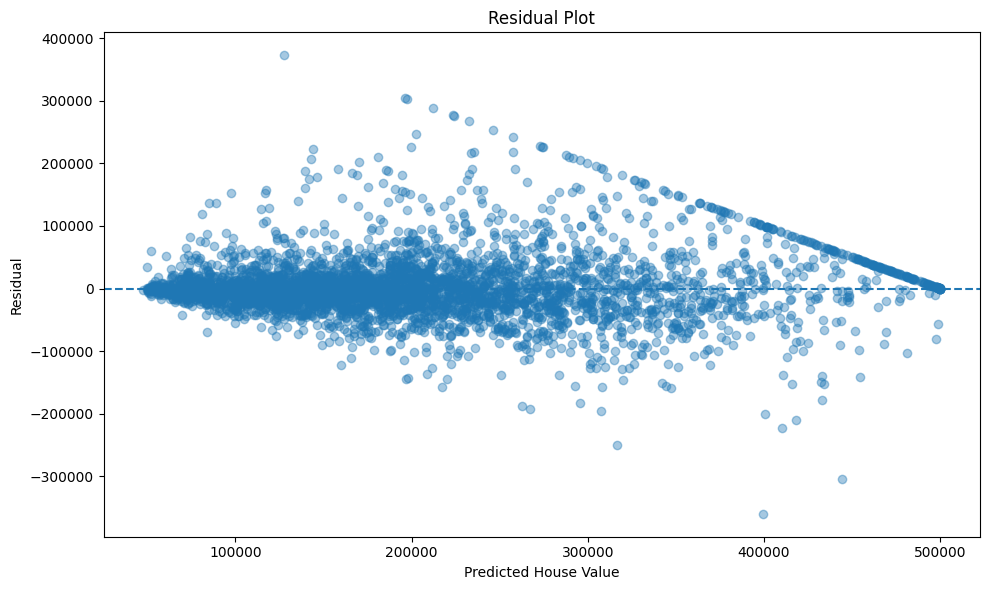

In [140]:
plt.figure(figsize=(10, 6))

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

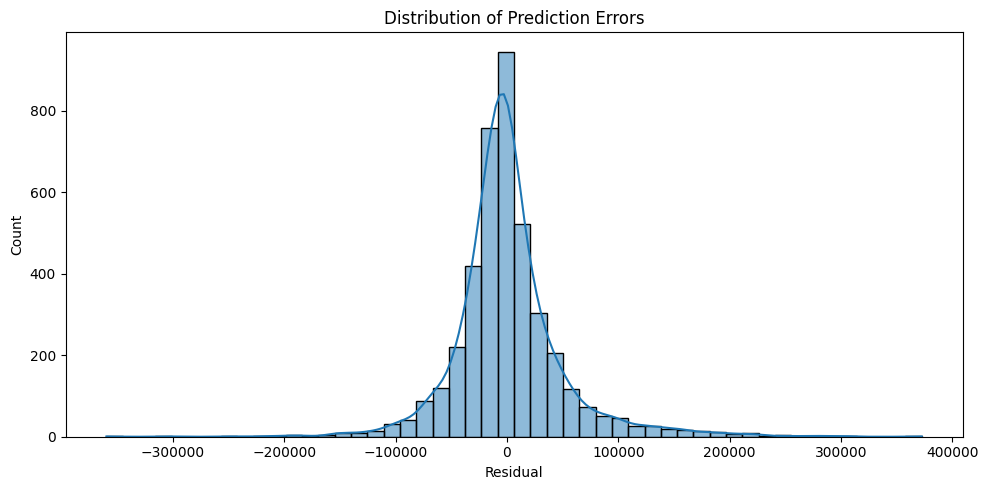

In [141]:
plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [142]:
residual_summary = pd.Series({
    "Mean Residual": residuals.mean(),
    "Median Residual": residuals.median(),
    "Residual Std": residuals.std(),
    "Mean Absolute Residual": np.abs(residuals).mean(),
    "90th Percentile Absolute Error": np.percentile(
        np.abs(residuals),
        90
    )
})

display(
    residual_summary.to_frame(
        name="Value"
    )
)

,Value
Mean Residual,1321.672880
Median Residual,-2774.791071
Residual Std,49625.282720
Mean Absolute Residual,32079.781672
90th Percentile Absolute Error,74836.742649


## Error by House Value Range

Prediction errors are analyzed across different house-value ranges to determine whether model performance changes for lower-priced and higher-priced districts.

In [143]:
error_analysis = pd.DataFrame({

    "Actual": test_target.values,

    "Predicted": test_predictions,

    "Residual": residuals.values,

    "Absolute Error": np.abs(
        residuals.values
    )

})

error_analysis["Price Range"] = pd.cut(

    error_analysis["Actual"],

    bins=[
        0,
        100000,
        200000,
        300000,
        400000,
        np.inf
    ],

    labels=[
        "< $100k",
        "$100k–$200k",
        "$200k–$300k",
        "$300k–$400k",
        "$400k+"
    ]

)

price_range_errors = (

    error_analysis

    .groupby(
        "Price Range",
        observed=True
    )

    .agg(
        Count=("Actual", "size"),
        MAE=("Absolute Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )

)

display(price_range_errors)

,Count,MAE,Mean_Residual
Price Range,,,
< $100k,765,19251.257590,-15937.112975
$100k–$200k,1603,24239.887094,-10902.886622
$200k–$300k,987,33721.781798,425.511191
$300k–$400k,413,50216.435347,26110.312543
$400k+,360,68941.114557,66448.738069


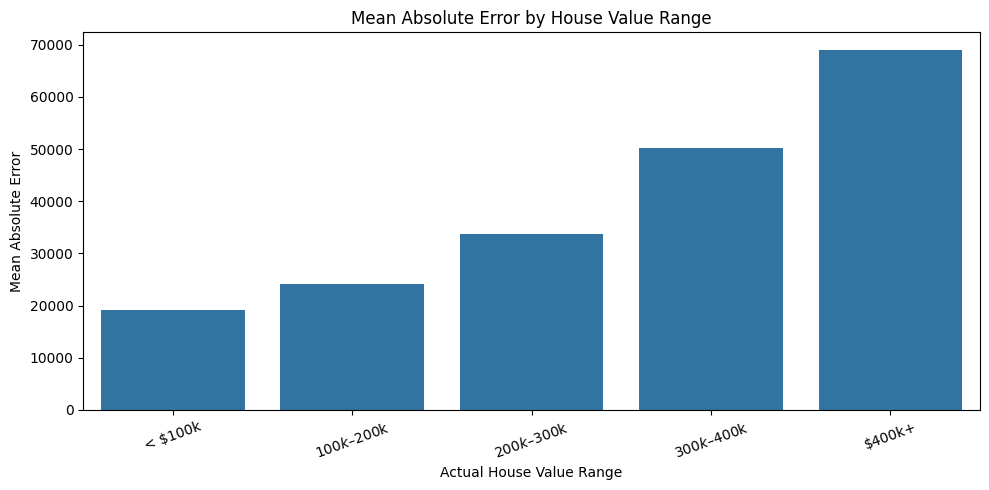

In [144]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=price_range_errors.reset_index(),
    x="Price Range",
    y="MAE"
)

plt.title(
    "Mean Absolute Error by House Value Range"
)

plt.xlabel("Actual House Value Range")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [145]:
underprediction_rate = (
    residuals > 0
).mean() * 100

overprediction_rate = (
    residuals < 0
).mean() * 100

print(
    f"Underpredictions: "
    f"{underprediction_rate:.2f}%"
)

print(
    f"Overpredictions: "
    f"{overprediction_rate:.2f}%"
)

print(
    f"Mean residual: "
    f"${residuals.mean():,.2f}"
)

Underpredictions: 45.11%
Overpredictions: 54.70%
Mean residual: $1,321.67


In [146]:
worst_indices = (
    error_analysis
    .nlargest(
        10,
        "Absolute Error"
    )
    .index
)

worst_cases = (
    test_features
    .reset_index(drop=True)
    .iloc[worst_indices]
    .copy()
)

worst_cases["Actual"] = (
    error_analysis
    .iloc[worst_indices]["Actual"]
    .values
)

worst_cases["Predicted"] = (
    error_analysis
    .iloc[worst_indices]["Predicted"]
    .values
)

worst_cases["Absolute Error"] = (
    error_analysis
    .iloc[worst_indices]["Absolute Error"]
    .values
)

display(worst_cases)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,Actual,Predicted,Absolute Error
1578,-120.10,38.91,33.0,1561.0,282.0,30.0,11.0,1.8750,INLAND,500001.0,127497.987631,372503.012369
2465,-122.06,37.39,22.0,1236.0,290.0,413.0,274.0,3.6875,NEAR BAY,40000.0,399702.059115,359702.059115
1560,-118.38,34.02,31.0,1893.0,450.0,819.0,426.0,4.3077,<1H OCEAN,140600.0,444356.780363,303756.780363
3387,-117.55,33.83,6.0,502.0,76.0,228.0,65.0,4.2386,INLAND,500001.0,196267.947838,303733.052162
2424,-120.16,34.61,17.0,921.0,189.0,434.0,219.0,3.0185,NEAR OCEAN,500001.0,197423.958720,302577.041280
651,-121.90,37.39,42.0,42.0,14.0,26.0,14.0,1.7361,<1H OCEAN,500001.0,212050.676417,287950.323583
2124,-122.26,37.55,17.0,1321.0,425.0,683.0,408.0,4.7045,NEAR BAY,500001.0,223322.652996,276678.347004
322,-122.03,37.37,16.0,3402.0,1193.0,1479.0,1043.0,3.5861,<1H OCEAN,500001.0,223863.029524,276137.970476
2256,-119.55,34.38,17.0,1951.0,368.0,681.0,350.0,2.7275,<1H OCEAN,500001.0,232784.439976,267216.560024
2664,-119.67,34.47,35.0,2700.0,422.0,1995.0,383.0,4.9757,<1H OCEAN,500001.0,246063.494345,253937.505655


# Feature Importance

,Feature,Importance
7,log_features__median_income,0.480313
10,categorical__ocean_proximity_INLAND,0.145839
2,people_per_house__ratio,0.122533
14,remainder__longitude,0.063449
15,remainder__latitude,0.059358
8,housing_age_rbf__housing_median_age,0.033390
1,rooms_per_house__ratio,0.027020
0,bedrooms_per_room__ratio,0.021776
4,log_features__total_rooms,0.011704
5,log_features__population,0.011298


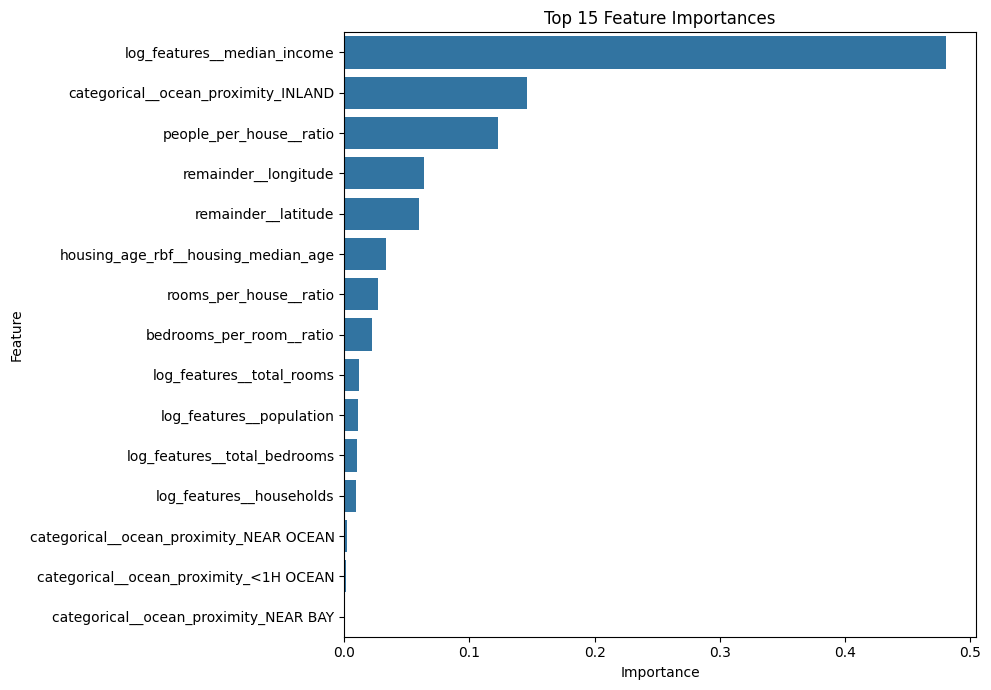

In [147]:
if hasattr(
    final_model.named_steps["model"],
    "feature_importances_"
):

    feature_importance = pd.DataFrame({

        "Feature":
            final_model.named_steps[
                "preprocessing"
            ].get_feature_names_out(),

        "Importance":
            final_model.named_steps[
                "model"
            ].feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    display(
        feature_importance.head(20)
    )

    top_features = feature_importance.head(15)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Top 15 Feature Importances"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "The selected model does not provide "
        "tree-based feature_importances_."
    )

In [148]:
feature_importance = pd.DataFrame({

    "Feature": final_model.named_steps[

        "preprocessing"

    ].get_feature_names_out(),

    "Importance": final_model.named_steps[

        "model"

    ].feature_importances_
})

feature_importance = feature_importance.sort_values(

    "Importance",

    ascending=False

)

display(
    feature_importance.head(20)
)

,Feature,Importance
7,log_features__median_income,0.480313
10,categorical__ocean_proximity_INLAND,0.145839
2,people_per_house__ratio,0.122533
14,remainder__longitude,0.063449
15,remainder__latitude,0.059358
8,housing_age_rbf__housing_median_age,0.033390
1,rooms_per_house__ratio,0.027020
0,bedrooms_per_room__ratio,0.021776
4,log_features__total_rooms,0.011704
5,log_features__population,0.011298


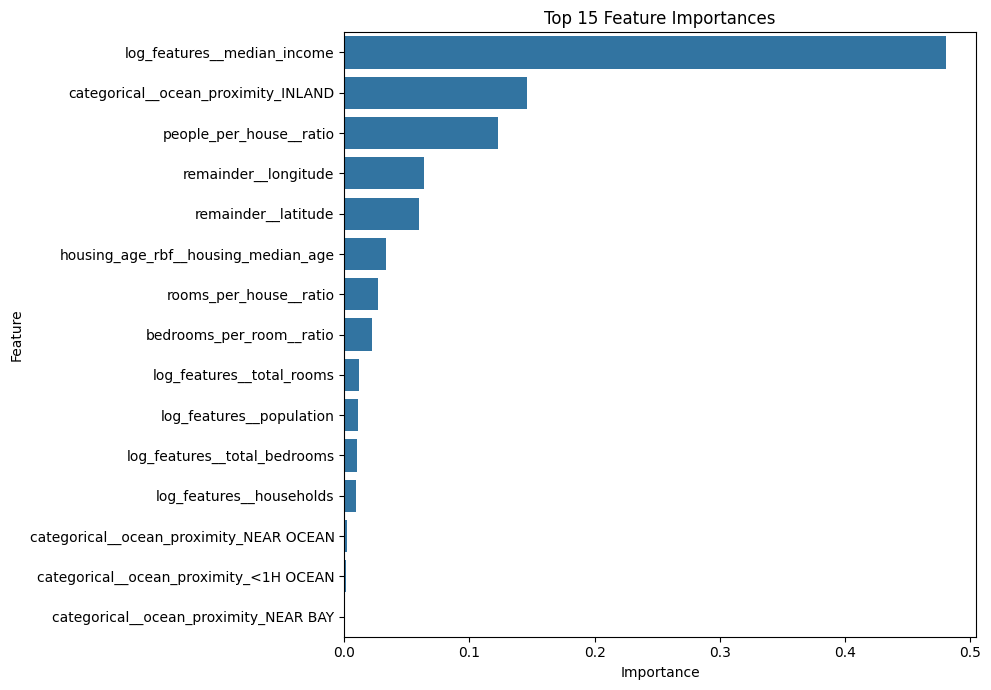

In [149]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")

plt.tight_layout()
plt.show()

# Permutation Importance


In [150]:
permutation = permutation_importance(

    final_model,

    test_features,

    test_target,

    n_repeats=10,

    random_state=40,

    scoring="neg_mean_absolute_error",

    n_jobs=-1

)

permutation_importance_df = pd.DataFrame({

    "Feature": test_features.columns,

    "Importance": permutation.importances_mean,

    "Std": permutation.importances_std

})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    permutation_importance_df
)

,Feature,Importance,Std
7,median_income,40838.455795,599.007843
5,population,25835.483304,648.602004
6,households,22410.988976,480.310460
1,latitude,19488.990890,419.067130
0,longitude,17347.506523,544.174159
8,ocean_proximity,16416.839145,617.425723
3,total_rooms,10661.313120,214.043558
4,total_bedrooms,4650.674937,152.060161
2,housing_median_age,3054.565249,185.917729


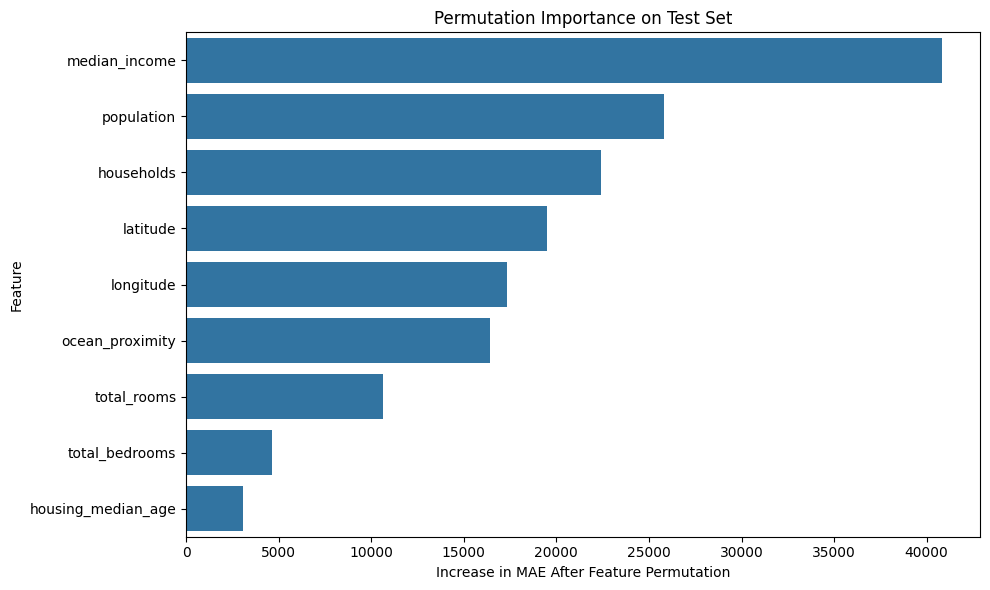

In [151]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=permutation_importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Permutation Importance on Test Set"
)

plt.xlabel(
    "Increase in MAE After Feature Permutation"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Save Best Model

In [152]:
MODEL_PATH = "models/california_housing_model.pkl"

os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: models/california_housing_model.pkl


# Load Model

In [153]:
loaded_model = joblib.load(
    MODEL_PATH
)

In [154]:
sample_data = test_features.iloc[:5]

sample_predictions = loaded_model.predict(
    sample_data
)

prediction_table = pd.DataFrame({
    "Actual Price": test_target.iloc[:5].values,
    "Predicted Price": np.round(
        sample_predictions,
        0
    )
})

display(prediction_table)

,Actual Price,Predicted Price
0,160300.0,158212.0
1,150000.0,149707.0
2,311300.0,258348.0
3,149000.0,127018.0
4,112500.0,106753.0


In [155]:
original_sample_predictions = (
    final_model.predict(sample_data)
)

loaded_sample_predictions = (
    loaded_model.predict(sample_data)
)

predictions_match = np.allclose(
    original_sample_predictions,
    loaded_sample_predictions
)

print(
    "Loaded model reproduces original predictions:",
    predictions_match
)

Loaded model reproduces original predictions: True


# Model Persistence and Inference

The trained pipeline is saved using Joblib and loaded again to verify that the complete preprocessing and prediction pipeline can be reused for inference.